# Mustache Detector v2
Förbättringar mot v1:
- Clean-klassen inkluderar nu män med skägg men UTAN mustasch
- Data augmentation med rotation, flip, zoom, brightness
- Dropout för regularisering

In [47]:
import pandas as pd
import os
import shutil
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

print('TensorFlow:', tf.__version__)

TensorFlow: 2.16.2


## Ladda labels

In [48]:
labels = pd.read_csv('data/list_attr_celeba.csv')
source_dir = 'data/img/img_align_celeba'

men   = labels[labels['Male'] ==  1]
women = labels[labels['Male'] == -1]
print('Totalt män:', len(men))
print('Totalt kvinnor:', len(women))

Totalt män: 84434
Totalt kvinnor: 118165


## Förbättrat urval v3
**V2:** clean = män utan mustasch

**V3:** clean = män utan mustasch + 1000 kvinnor → modellen lär sig att kvinnor sällan har mustasch

In [49]:
mustache_df = men[men['Mustache'] == 1]

men_clean   = men[men['Mustache'] == -1]
women_clean = women[women['Mustache'] == -1].sample(n=1382, random_state=42)

clean_df = pd.concat([men_clean, women_clean])

print('Mustasch:', len(mustache_df))
print('Ingen mustasch (v3):', len(clean_df))

Mustasch: 8414
Ingen mustasch (v3): 77402


In [50]:
mustache_sample = mustache_df.sample(n=5000, random_state=42)
clean_sample    = clean_df.sample(n=5000, random_state=42)

print('Mustasch sample:', len(mustache_sample))
print('Clean sample:', len(clean_sample))

Mustasch sample: 5000
Clean sample: 5000


## Kopiera bilder till nytt dataset

In [17]:
os.makedirs('data/dataset_v2/mustache', exist_ok=True)
os.makedirs('data/dataset_v2/clean', exist_ok=True)

for filename in mustache_sample['image_id']:
    src = os.path.join(source_dir, filename)
    dst = os.path.join('data/dataset_v2/mustache', filename)
    if os.path.exists(src):
        shutil.copy2(src, dst)

for filename in clean_sample['image_id']:
    src = os.path.join(source_dir, filename)
    dst = os.path.join('data/dataset_v2/clean', filename)
    if os.path.exists(src):
        shutil.copy2(src, dst)

print('Mustache:', len(os.listdir('data/dataset_v2/mustache')))
print('Clean:', len(os.listdir('data/dataset_v2/clean')))

Mustache: 5000
Clean: 5000


## Ladda dataset

In [38]:
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    'data/dataset_v2',
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    'data/dataset_v2',
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

print('Klasser:', train_ds.class_names)

Found 11382 files belonging to 2 classes.
Using 9106 files for training.
Found 11382 files belonging to 2 classes.
Using 2276 files for validation.
Klasser: ['clean', 'mustache']


## Bygg modellen v2
Samma CNN-arkitektur som v1 men med augmentation och dropout

In [39]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),   # ±36 grader — hjälper med vinklade huvuden
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomBrightness(0.2),
    tf.keras.layers.RandomContrast(0.2),
])

model_v2 = tf.keras.Sequential([
    data_augmentation,
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_v2.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Träna

In [40]:
model_v2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
285/285 ━━━━━━━━━━━━━━━━━━━━ 55s 185ms/step - accuracy: 0.5976 - loss: 0.6542 - val_accuracy: 0.6555 - val_loss: 0.6162
Epoch 2/30
285/285 ━━━━━━━━━━━━━━━━━━━━ 53s 186ms/step - accuracy: 0.7631 - loss: 0.5001 - val_accuracy: 0.8300 - val_loss: 0.3862
Epoch 3/30
285/285 ━━━━━━━━━━━━━━━━━━━━ 57s 201ms/step - accuracy: 0.8131 - loss: 0.4213 - val_accuracy: 0.8396 - val_loss: 0.3614
Epoch 4/30
285/285 ━━━━━━━━━━━━━━━━━━━━ 52s 181ms/step - accuracy: 0.8223 - loss: 0.3972 - val_accuracy: 0.8497 - val_loss: 0.3282
Epoch 5/30
285/285 ━━━━━━━━━━━━━━━━━━━━ 52s 181ms/step - accuracy: 0.8387 - loss: 0.3662 - val_accuracy: 0.8656 - val_loss: 0.2946
Epoch 6/30
285/285 ━━━━━━━━━━━━━━━━━━━━ 54s 188ms/step - accuracy: 0.8511 - loss: 0.3428 - val_accuracy: 0.8757 - val_loss: 0.2943
Epoch 7/30
285/285 ━━━━━━━━━━━━━━━━━━━━ 51s 180ms/step - accuracy: 0.8608 - loss: 0.3193 - val_accuracy: 0.8721 - val_loss: 0.3033
Epoch 8/30
285/285 ━━━━━━━━━━━━━━━━━━━━ 53s 185ms/step - accuracy: 0.8673 - loss: 0

## Utvärdering

In [41]:
loss, acc = model_v2.evaluate(val_ds)

print(f'V2 accuracy: {acc*100:.1f}%')

72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9139 - loss: 0.2093
V2 accuracy: 91.4%


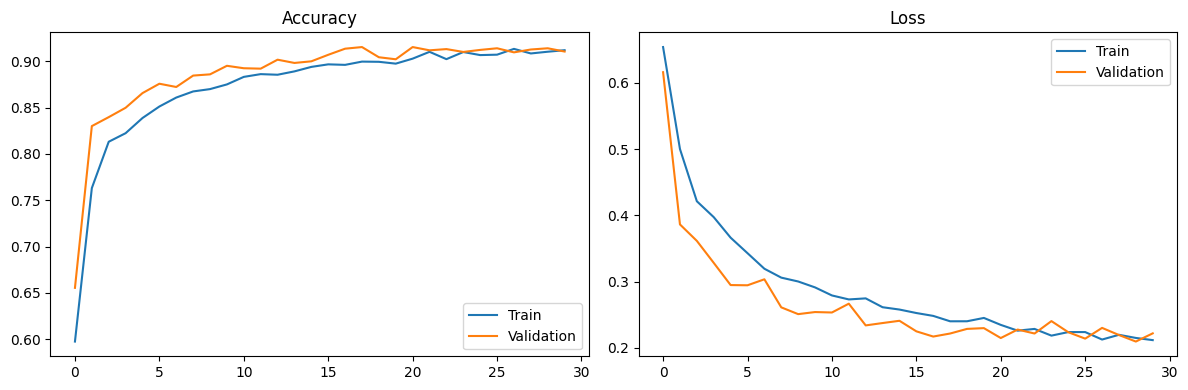

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

2026-06-07 04:48:16.023024: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


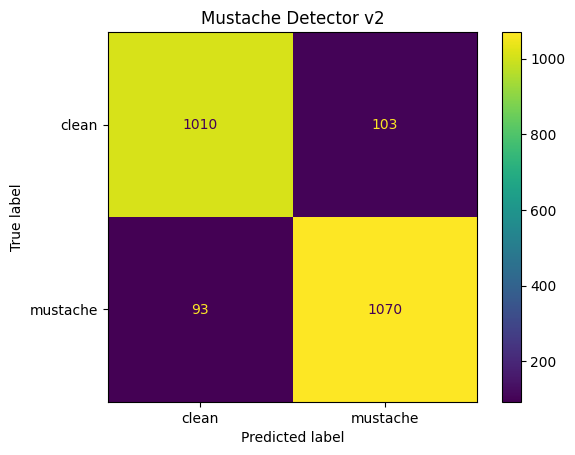

In [43]:
y_true, y_pred = [], []

for images, labels_batch in val_ds:
    preds = model_v2.predict(images, verbose=0).flatten()
    y_true.extend(labels_batch.numpy().astype(int))
    y_pred.extend((preds > 0.5).astype(int))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=val_ds.class_names
)
disp.plot(values_format='d')
plt.title('Mustache Detector v2')
plt.show()

## Spara — skriver över mustache_detector.keras
Kör bara denna om v2 är bättre än v1!

2026-06-07 04:49:43.064243: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


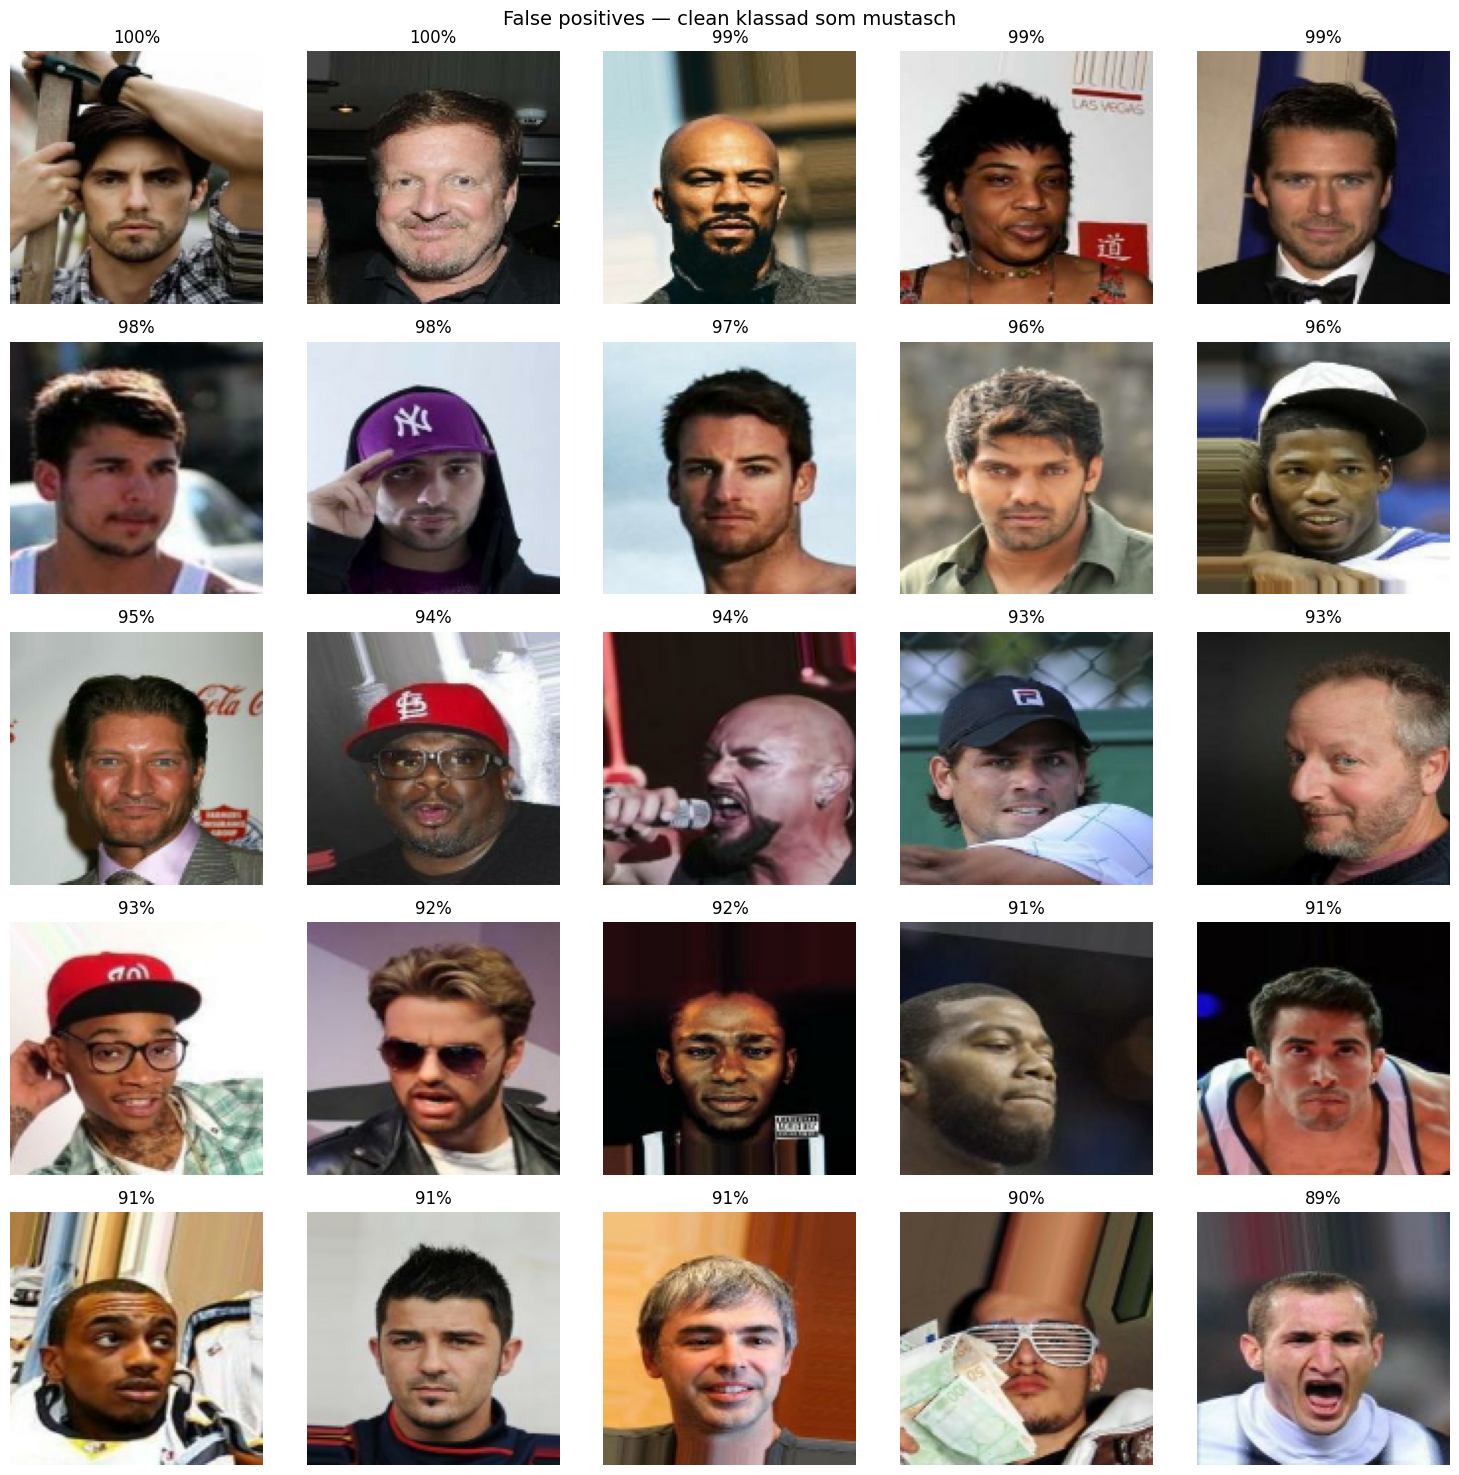

In [45]:
images_list, true_labels, pred_probs = [], [], []

for images, labels_batch in val_ds:
    preds = model_v2.predict(images, verbose=0).flatten()
    images_list.append(images.numpy())
    true_labels.append(labels_batch.numpy().flatten())
    pred_probs.append(preds)

images_arr = np.concatenate(images_list)
true_arr   = np.concatenate(true_labels)
pred_arr   = np.concatenate(pred_probs)

# class_names: ['clean', 'mustache'] → clean=0, mustache=1
# False positives: true=clean (0) men modellen säger mustache (>0.5)
fp_idx = np.where((true_arr == 0) & (pred_arr > 0.5))[0]
fp_sorted = fp_idx[np.argsort(pred_arr[fp_idx])[::-1]]

plt.figure(figsize=(15, 15))
for i, idx in enumerate(fp_sorted[:25]):
    plt.subplot(5, 5, i + 1)
    plt.imshow(images_arr[idx].astype('uint8'))
    plt.title(f'{pred_arr[idx]*100:.0f}%')
    plt.axis('off')
plt.suptitle('False positives — clean klassad som mustasch', fontsize=14)
plt.tight_layout()
plt.show()

In [44]:
model_v2.save('models/mustache_detector2.keras')
print('Sparad!')

Sparad!


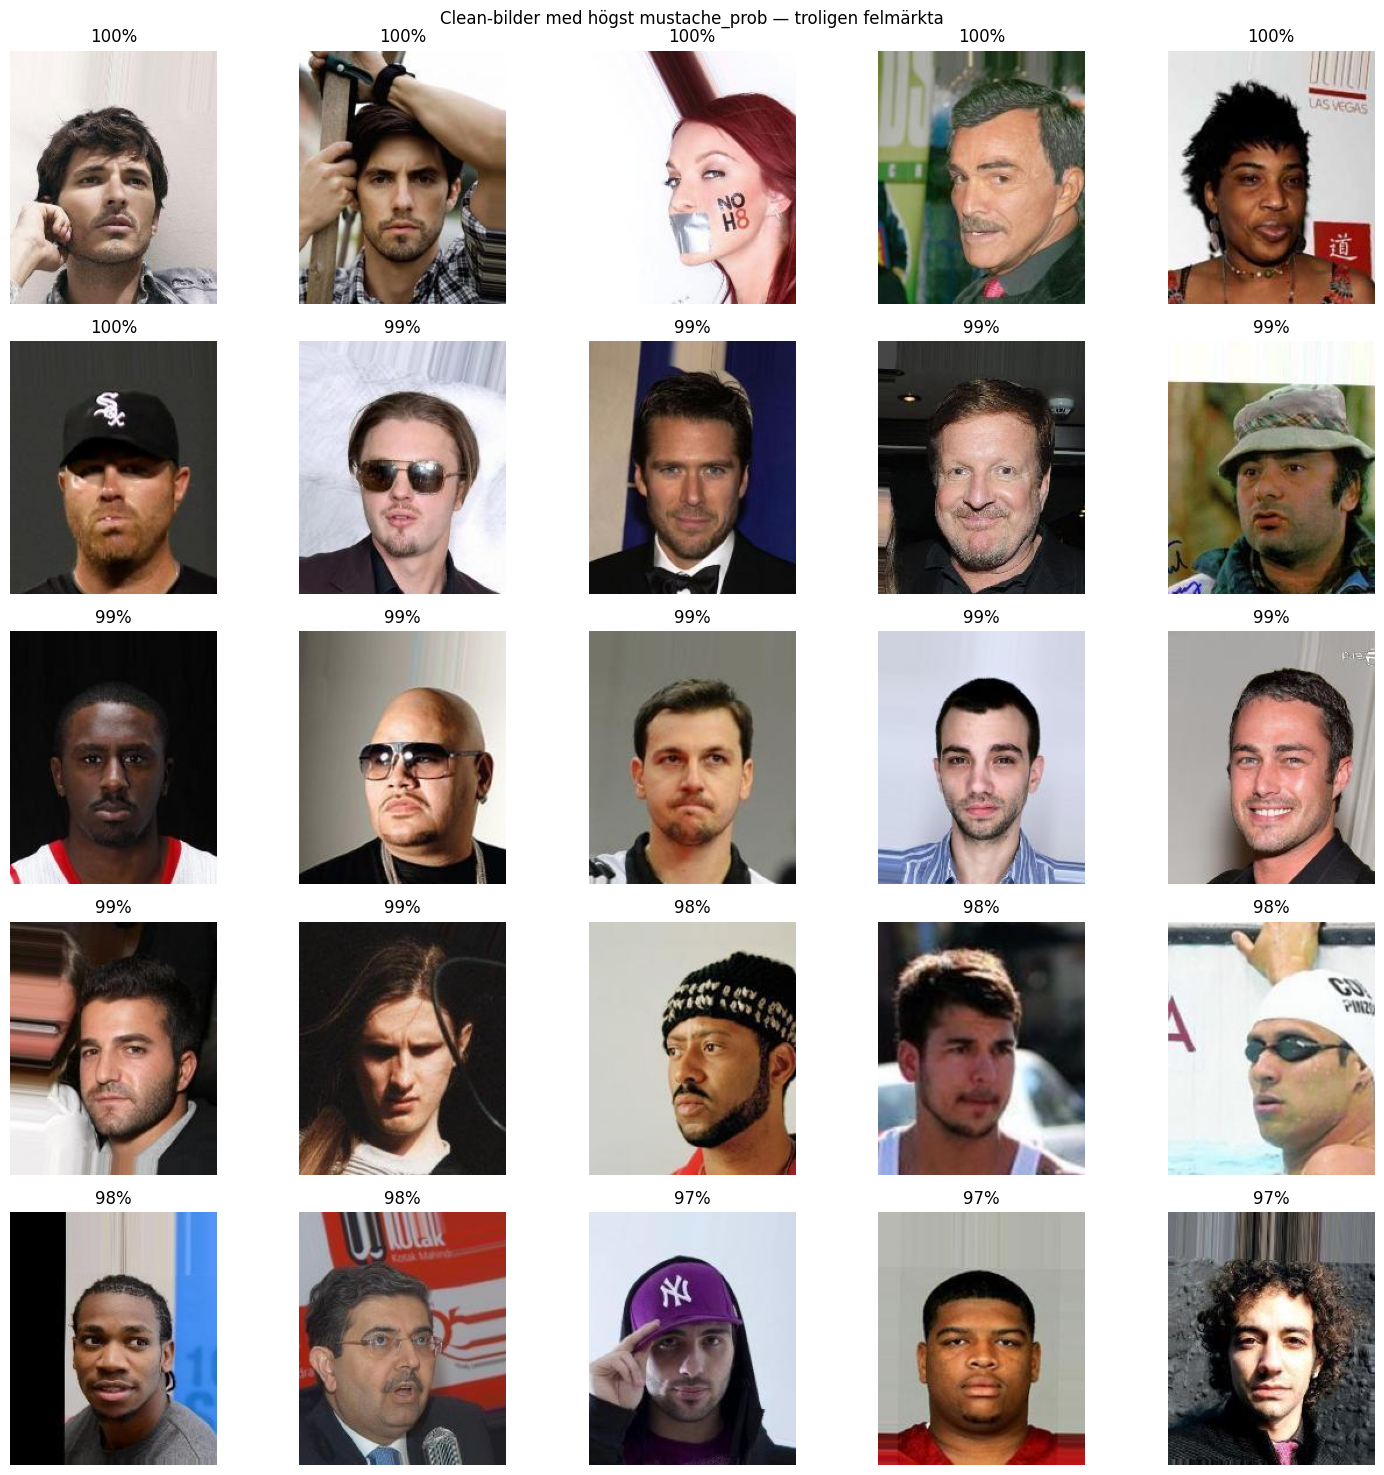

In [46]:
from PIL import Image

clean_dir = 'data/dataset_v2/clean'
clean_files = os.listdir(clean_dir)

scores = []
for fname in clean_files:
    path = os.path.join(clean_dir, fname)
    img = tf.keras.utils.load_img(path, target_size=(128, 128))
    arr = np.expand_dims(tf.keras.utils.img_to_array(img), axis=0)
    prob = float(model_v2.predict(arr, verbose=0)[0][0])
    scores.append((fname, prob))

# Sortera — högst score = troligen felmärkta
scores.sort(key=lambda x: x[1], reverse=True)

# Visa topp 50
plt.figure(figsize=(15, 15))
for i, (fname, score) in enumerate(scores[:25]):
    path = os.path.join(clean_dir, fname)
    img = Image.open(path)
    plt.subplot(5, 5, i + 1)
    plt.imshow(img)
    plt.title(f'{score*100:.0f}%')
    plt.axis('off')
plt.suptitle('Clean-bilder med högst mustache_prob — troligen felmärkta', fontsize=12)
plt.tight_layout()
plt.show()

In [29]:
clean_dir = 'data/dataset_v2/clean'
clean_files = os.listdir(clean_dir)

scores = []
for i, fname in enumerate(clean_files):
    path = os.path.join(clean_dir, fname)
    img = tf.keras.utils.load_img(path, target_size=(128, 128))
    arr = np.expand_dims(tf.keras.utils.img_to_array(img), axis=0)
    prob = float(model_v2.predict(arr, verbose=0)[0][0])
    scores.append((fname, prob))
    if (i + 1) % 500 == 0:
        print(f'{i+1}/{len(clean_files)} klara...')

clean_scores = sorted(scores, key=lambda x: x[1], reverse=True)
print('Klart!')

500/5000 klara...
1000/5000 klara...
1500/5000 klara...
2000/5000 klara...
2500/5000 klara...
3000/5000 klara...
3500/5000 klara...
4000/5000 klara...
4500/5000 klara...
5000/5000 klara...
Klart!


In [30]:
for threshold in [0.5, 0.6, 0.7, 0.8, 0.9]:
    count = sum(1 for _, score in clean_scores if score > threshold)
    print(f">{threshold*100:.0f}% mustache_prob: {count} bilder ({count/len(clean_scores)*100:.1f}%)")

>50% mustache_prob: 1282 bilder (25.6%)
>60% mustache_prob: 991 bilder (19.8%)
>70% mustache_prob: 691 bilder (13.8%)
>80% mustache_prob: 416 bilder (8.3%)
>90% mustache_prob: 142 bilder (2.8%)


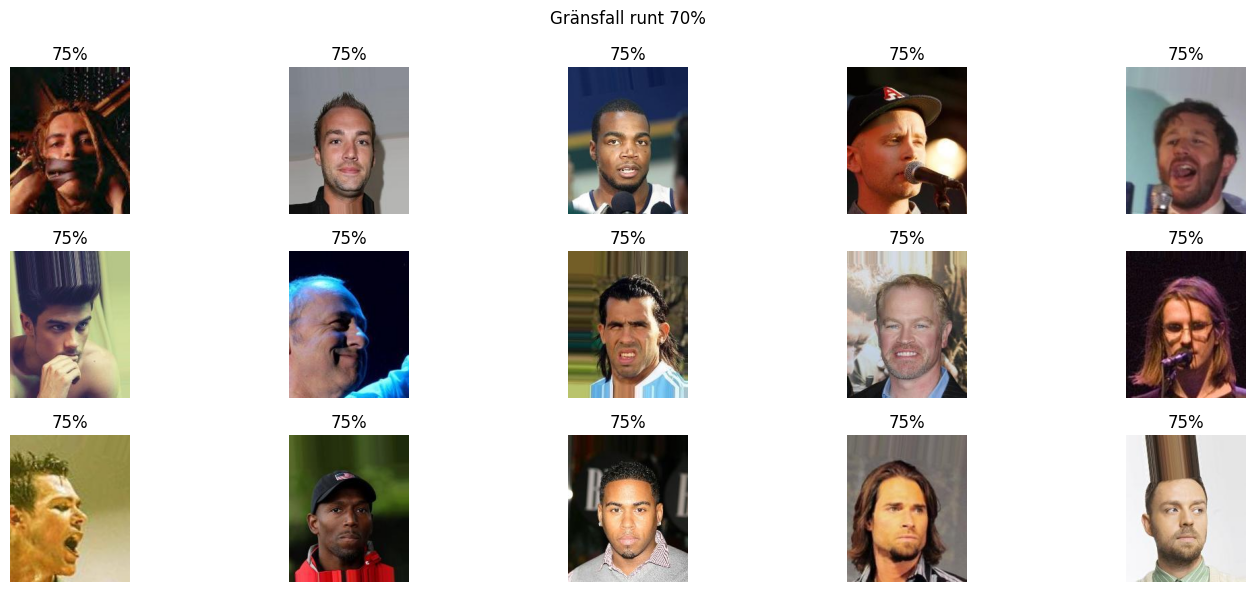

In [31]:
# Visa bilder runt 70%-gränsen
border = [(f, s) for f, s in clean_scores if 0.65 < s < 0.75]

plt.figure(figsize=(15, 6))
for i, (fname, score) in enumerate(border[:15]):
    path = os.path.join(clean_dir, fname)
    img = Image.open(path)
    plt.subplot(3, 5, i + 1)
    plt.imshow(img)
    plt.title(f'{score*100:.0f}%')
    plt.axis('off')
plt.suptitle('Gränsfall runt 70%', fontsize=12)
plt.tight_layout()
plt.show()

In [32]:
import shutil

mustache_dir = 'data/dataset_v2/mustache'
threshold = 0.7

to_move = [(f, s) for f, s in clean_scores if s > threshold]

for fname, score in to_move:
    src = os.path.join(clean_dir, fname)
    dst = os.path.join(mustache_dir, fname)
    shutil.move(src, dst)

print(f'Flyttade {len(to_move)} bilder från clean → mustache')
print(f'Clean kvar: {len(os.listdir(clean_dir))}')
print(f'Mustache nu: {len(os.listdir(mustache_dir))}')

Flyttade 691 bilder från clean → mustache
Clean kvar: 4309
Mustache nu: 5691


In [37]:
# Kopiera BARA nya kvinno-bilder till clean — rör inte mustache!
women_clean = women[women['Mustache'] == -1].sample(n=1382, random_state=99)

for filename in women_clean['image_id']:
    src = os.path.join(source_dir, filename)
    dst = os.path.join('data/dataset_v2/clean', filename)
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.copy2(src, dst)

print(f'Clean nu: {len(os.listdir("data/dataset_v2/clean"))}')
print(f'Mustache nu: {len(os.listdir("data/dataset_v2/mustache"))}')

Clean nu: 5691
Mustache nu: 5691
